In [2]:
from aeloru_layer import AeloruLayer , AeloruConfig
import torch
import numbers as np

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_dim = 128
out_dim = 128

## Fisher VS HGF

测试 3: Hebbian-Fisher 双向联动（含 HGF 闭式 Fisher）
  [冲击前] Fisher 统计:
    均值: 0.000000
    方差: 0.00000000
    最大值: 0.000000
    最小值: 0.000000
  [Aeloru] Diagnostic @ step 0: {'state': 'explore', 'step': 0, 'w_acc_norm': 0.0, 'delta_w_norm': 0.0, 'fisher_mean': 9.92921257019043, 'fisher_max': 13.4375, 'grad_conflict': 0.0, 'homeostatic_gain_mean': 19.861774444580078}
  [第一次冲击后 (50步)] Fisher 统计:
    均值: 18.748215
    方差: 10.46554756
    最大值: 26.000000
    最小值: 12.000000
  [第二次持续冲击后 (100步)] Fisher 统计:
    均值: 18.940075
    方差: 19.42973900
    最大值: 28.250000
    最小值: 10.125000

测试 3.1: HGF 闭式更新验证
  [Aeloru] Diagnostic @ step 0: {'state': 'explore', 'step': 0, 'w_acc_norm': 0.0, 'delta_w_norm': 0.0, 'grad_conflict': 0.0, 'homeostatic_gain_mean': 19.738309860229492}
  [第一次冲击后 (50步)] Fisher 统计:
    均值: 18.940075
    方差: 19.42973900
    最大值: 28.250000
    最小值: 10.125000
  [Aeloru] Diagnostic @ step 100: {'state': 'explore', 'step': 100, 'w_acc_norm': 0.0, 'delta_w_norm': 0.0, 'grad_conflict': 0.0, 'ho

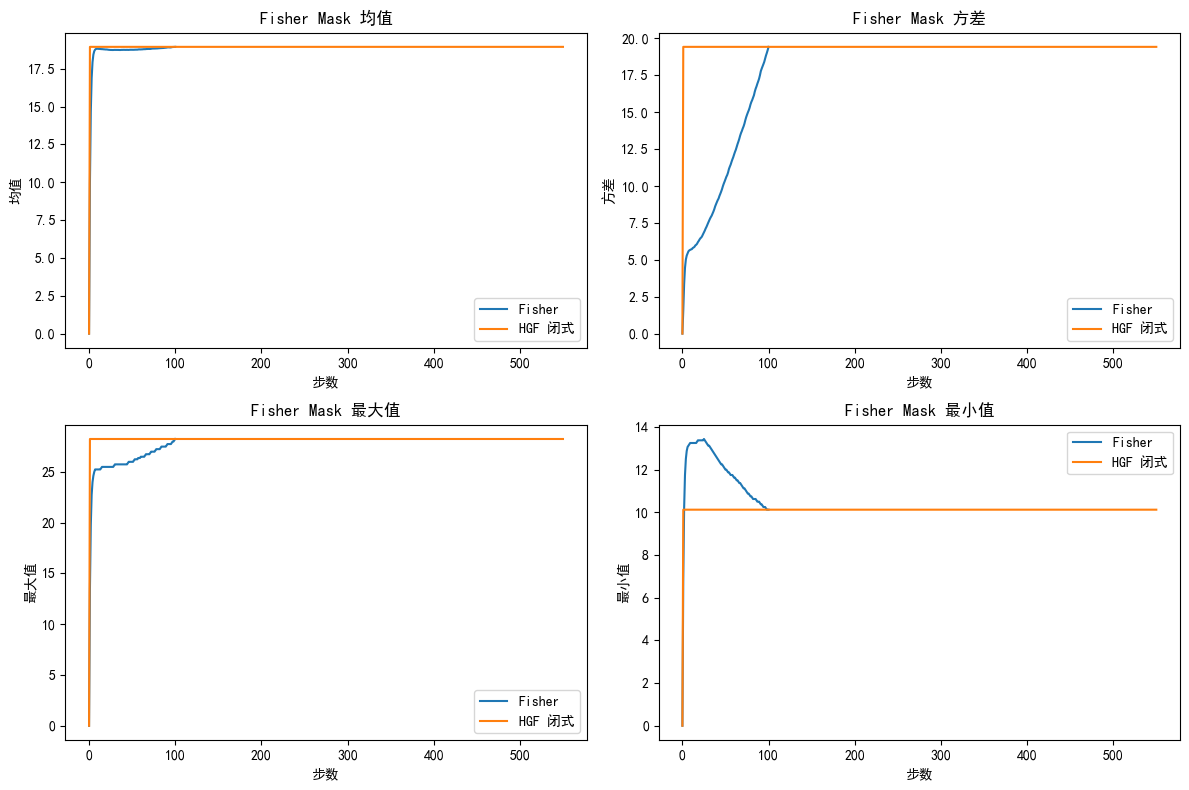

In [ ]:

cfg_hf = AeloruConfig(
    in_features=in_dim, 
    out_features=out_dim,
    r=8, 
    lora_alpha=4.0,
    fisher_gamma=0.5,
    use_hebbian=True,
    use_fisher=True,
    fisher_mode='full',
    use_hongwen=False,
    hebbian_lr=1e-2,
    hebbian_accum_steps=1,
    hebbian_before_backprop=True,
    use_hgf_fisher=True,
    use_homeostatic_plasticity=True,
)

batch_size = 16
layer_hf = AeloruLayer(in_dim, out_dim, cfg_hf).to(device)
layer_hf.set_pretrained_weight(torch.randn(out_dim, in_dim, device=device) * 0.02)
layer_hf.train()

def print_fisher_stats(tag: str):
    f = layer_hf.fisher_mask.float()
    print(f"  [{tag}] Fisher 统计:")
    print(f"    均值: {f.mean().item():.6f}")
    print(f"    方差: {f.var().item():.8f}")
    print(f"    最大值: {f.max().item():.6f}")
    print(f"    最小值: {f.min().item():.6f}")

print_fisher_stats("冲击前")

fixed_x = torch.randn(batch_size, in_dim, device=device, dtype=AeloruConfig.AMP_DTYPE)
hf_log_ms = [0]
hf_log_s_2 = [0]
hf_log_max =[0]
hf_log_min = [0]
# 第一次冲击
for _ in range(50):
    y = layer_hf(fixed_x)
    layer_hf.post_step_update(fixed_x, y, is_correct=True)
    f = layer_hf.fisher_mask.float()
    hf_log_ms.append(f.mean().item())
    hf_log_s_2.append(f.var().item())
    hf_log_max.append(f.max().item())
    hf_log_min.append(f.min().item())
print_fisher_stats("第一次冲击后 (50步)")

# 第二次冲击
for _ in range(50):
    y = layer_hf(fixed_x)
    layer_hf.post_step_update(fixed_x, y, is_correct=True)
    f = layer_hf.fisher_mask.float()
    hf_log_ms.append(f.mean().item())
    hf_log_s_2.append(f.var().item())
    hf_log_max.append(f.max().item())
    hf_log_min.append(f.min().item())

print_fisher_stats("第二次持续冲击后 (100步)")

#测试3 补充使用HGF 闭式更新验证 Hebbian-Fisher 双向联动
print("\n测试 3.1: HGF 闭式更新验证")
cfg_hf_hgf = AeloruConfig(
    in_features=in_dim, 
    out_features=out_dim,
    r=8, 
    lora_alpha=4.0,
    fisher_gamma=0.5,
    use_hebbian=True,
    use_fisher=False,  # 关闭常规 Fisher，验证 HGF 闭式路径
    fisher_mode='off',
    use_hgf_closed_form=True,
    use_hongwen=False,
    hebbian_lr=1e-2,
    hebbian_accum_steps=1,
    hebbian_before_backprop=True,
    use_hgf_fisher=True,
    use_homeostatic_plasticity=True,
)

hgf_log_ms = [0]
hgf_log_s_2 = [0]
hgf_log_max =[0]
hgf_log_min = [0]

layer_hf_hgf = AeloruLayer(in_dim, out_dim, cfg_hf_hgf).to(device)
layer_hf_hgf.set_pretrained_weight(torch.randn(out_dim, in_dim, device=device) * 0.02)
layer_hf_hgf.train()
# 第一次冲击
for _ in range(50):
    y = layer_hf_hgf(fixed_x)
    layer_hf_hgf.post_step_update(fixed_x, y, is_correct=True)
    try:
        f = layer_hf_hgf.fisher_mask.float()
    except:pass
    hgf_log_ms.append(f.mean().item())
    hgf_log_s_2.append(f.var().item())
    hgf_log_max.append(f.max().item())
    hgf_log_min.append(f.min().item())


print_fisher_stats("第一次冲击后 (50步)")

# 第二次冲击
for _ in range(500):
    y = layer_hf_hgf(fixed_x)
    layer_hf_hgf.post_step_update(fixed_x, y, is_correct=True)
    try:
        f = layer_hf_hgf.fisher_mask.float()
    except:pass
    hgf_log_ms.append(f.mean().item())
    hgf_log_s_2.append(f.var().item())
    hgf_log_max.append(f.max().item())
    hgf_log_min.append(f.min().item())

print_fisher_stats("第二次持续冲击后 (100步)")

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(hf_log_ms, label='Fisher')
plt.plot(hgf_log_ms, label='HGF 闭式')
plt.title('Fisher Mask 均值')
plt.xlabel('步数')
plt.ylabel('均值')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(hf_log_s_2, label='Fisher')
plt.plot(hgf_log_s_2, label='HGF 闭式')
plt.title('Fisher Mask 方差')
plt.xlabel('步数')
plt.ylabel('方差')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(hf_log_max, label='Fisher')
plt.plot(hgf_log_max, label='HGF 闭式')
plt.title('Fisher Mask 最大值')
plt.xlabel('步数')
plt.ylabel('最大值')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(hf_log_min, label='Fisher')
plt.plot(hgf_log_min, label='HGF 闭式')
plt.title('Fisher Mask 最小值')
plt.xlabel('步数')
plt.ylabel('最小值')
plt.legend()
plt.tight_layout()